In [1]:
from pathlib import Path 

import cv2 
import numpy as np
import IPython
from tqdm.auto import tqdm 
from retinaface import RetinaFace

/home/amos/anaconda3/envs/retina/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-03-02 18:23:28.914138: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-02 18:23:28.914162: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-02 18:23:28.914854: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-02 18:23:28.919259: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow b

In [2]:
def draw_faces(image, faces):
    for face, data in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = data['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
cap = cv2.VideoCapture('/home/amos/test.mkv')
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

False

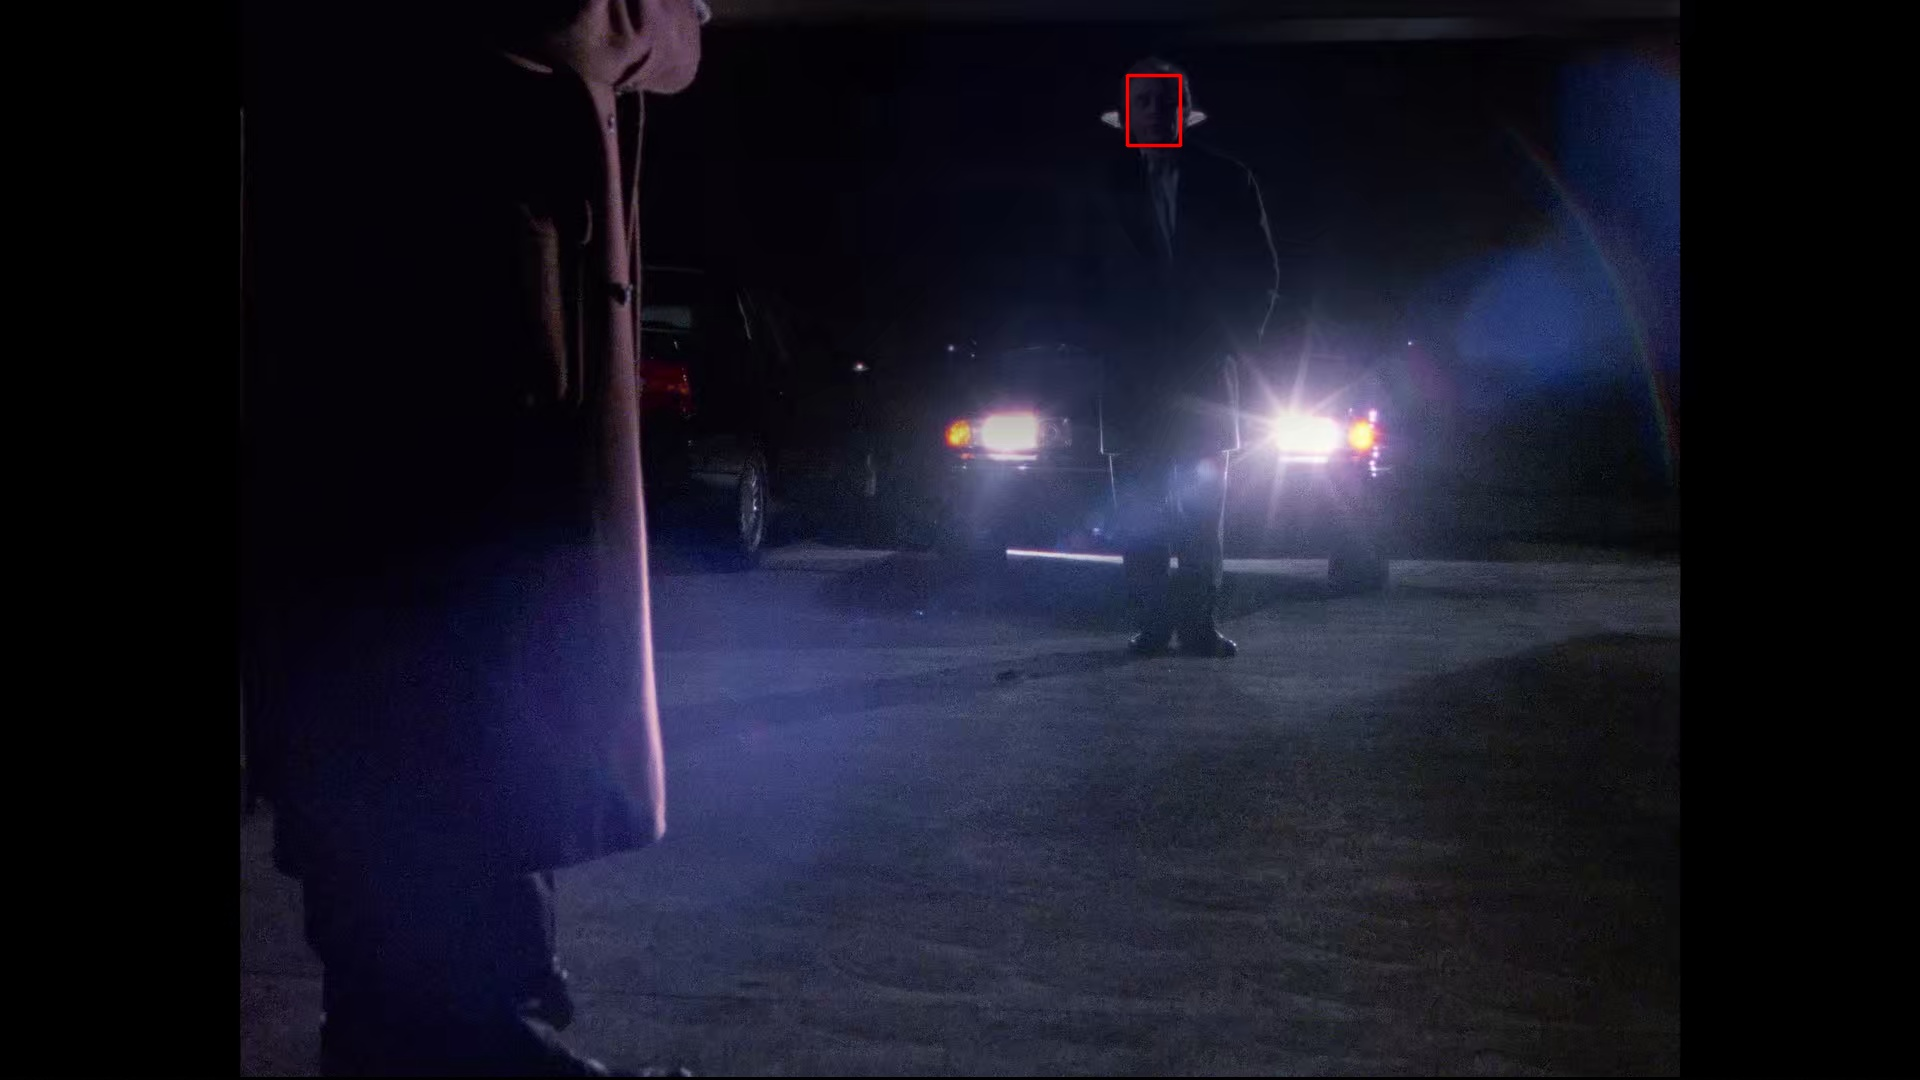

In [5]:
img = cv2.imread('../test_images/Frasier.S04E11.Three.Days.of.the.Condo.1080p.BluRay.10Bit.Dts-HDMa2.0.HEVC-d3g_14688.png')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

In [6]:
faces

{'face_1': {'score': 0.9911115765571594,
  'facial_area': [195, 78, 552, 538],
  'landmarks': {'right_eye': [278.75327, 229.81548],
   'left_eye': [460.6546, 235.79626],
   'nose': [361.41818, 317.60675],
   'mouth_right': [294.397, 423.1652],
   'mouth_left': [431.90906, 428.84247]}}}

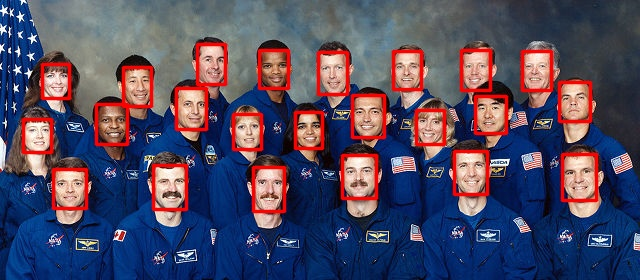

In [13]:
img = cv2.imread('./images/img_2.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

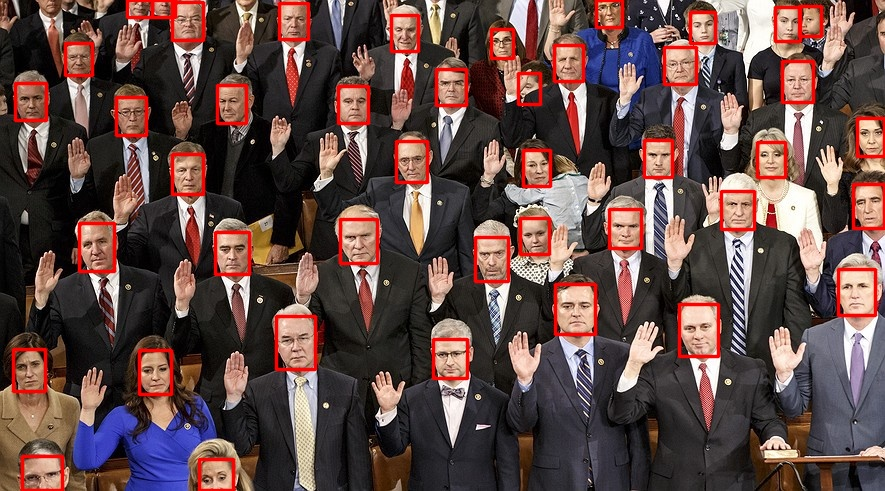

In [14]:
img = cv2.imread('./images/img_3.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

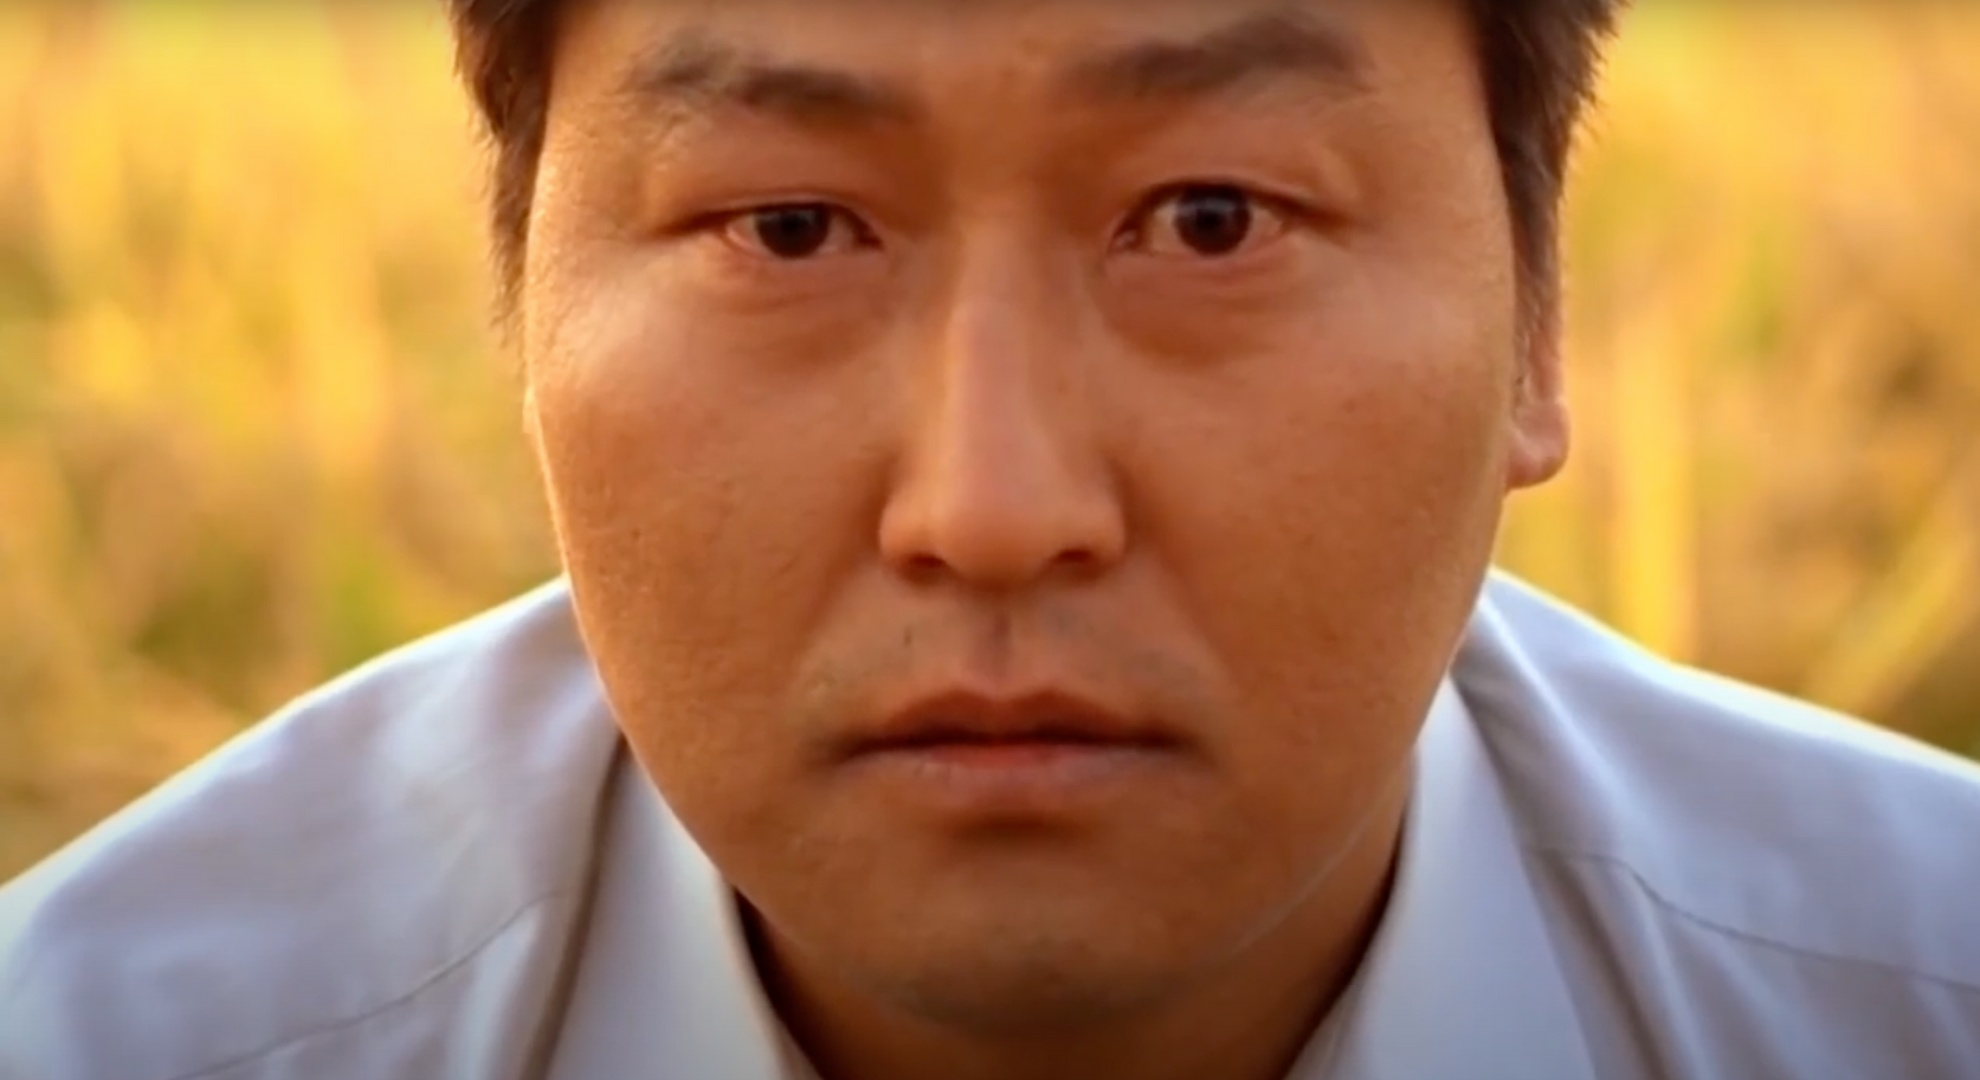

In [20]:
img = cv2.imread('./images/img_4.jpg')
faces = RetinaFace.detect_faces(img, threshold=0.1)
draw_faces(img, faces)
show_image(img)

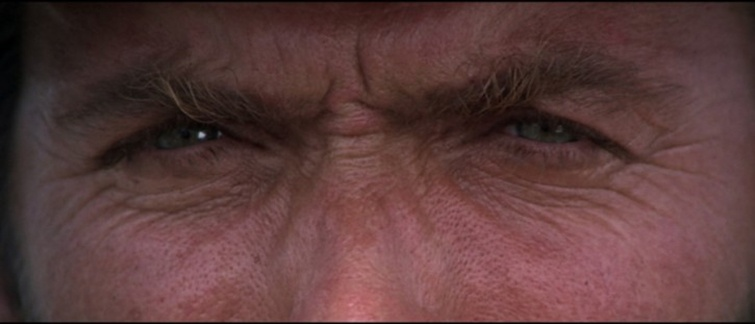

In [21]:
img = cv2.imread('./images/img_5.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

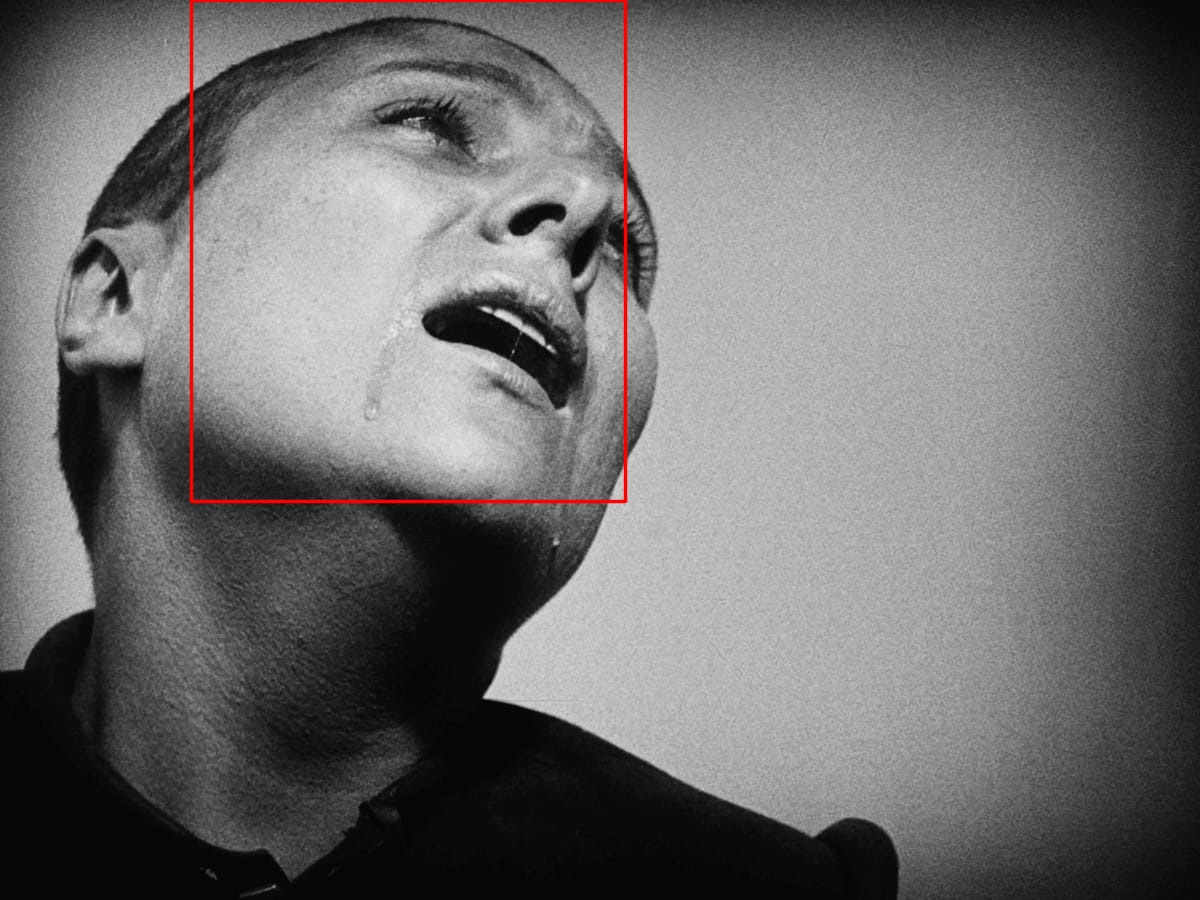

In [17]:
img = cv2.imread('./images/img_6.jpg')
faces = RetinaFace.detect_faces(img)
draw_faces(img, faces)
show_image(img)

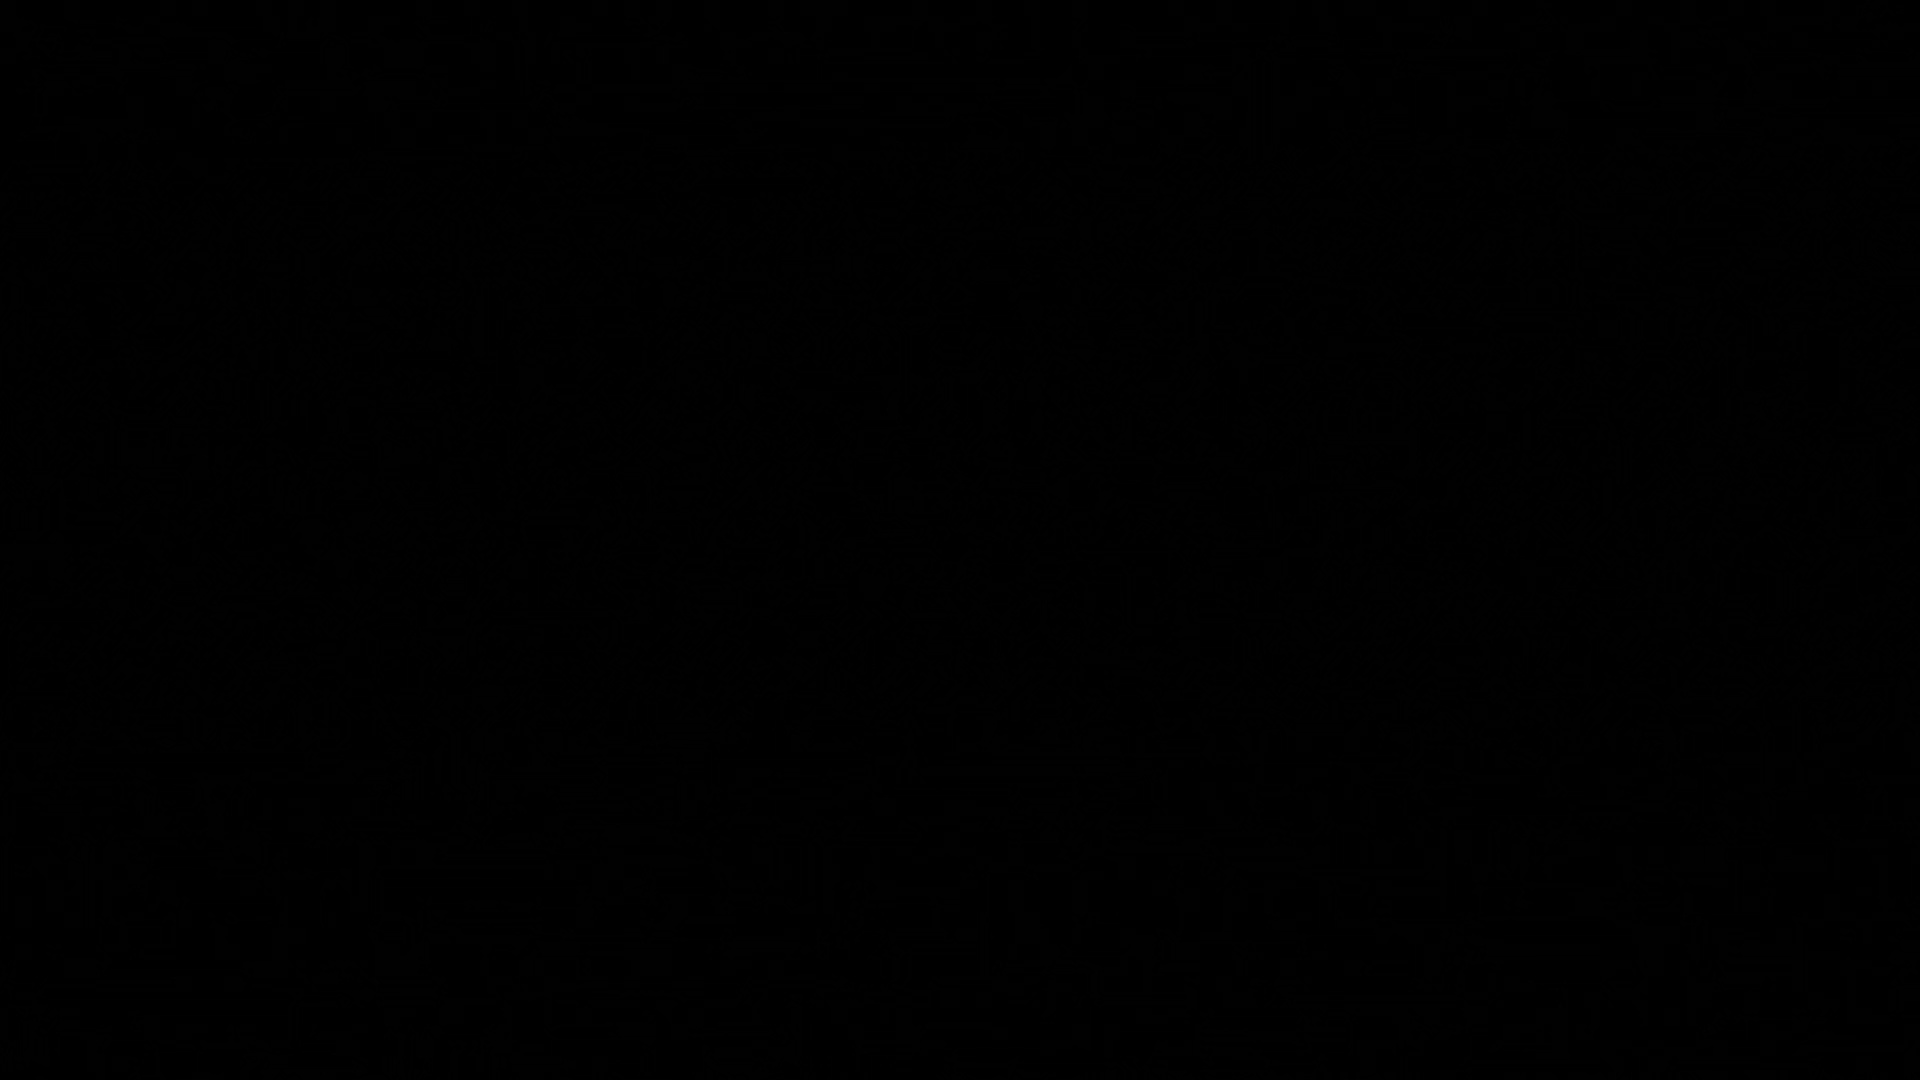

In [28]:
cap = cv2.VideoCapture('./data/test.mkv')
_, frame = cap.read()
show_image(frame)

  0%|          | 23/111290 [00:02<3:41:45,  8.36it/s]


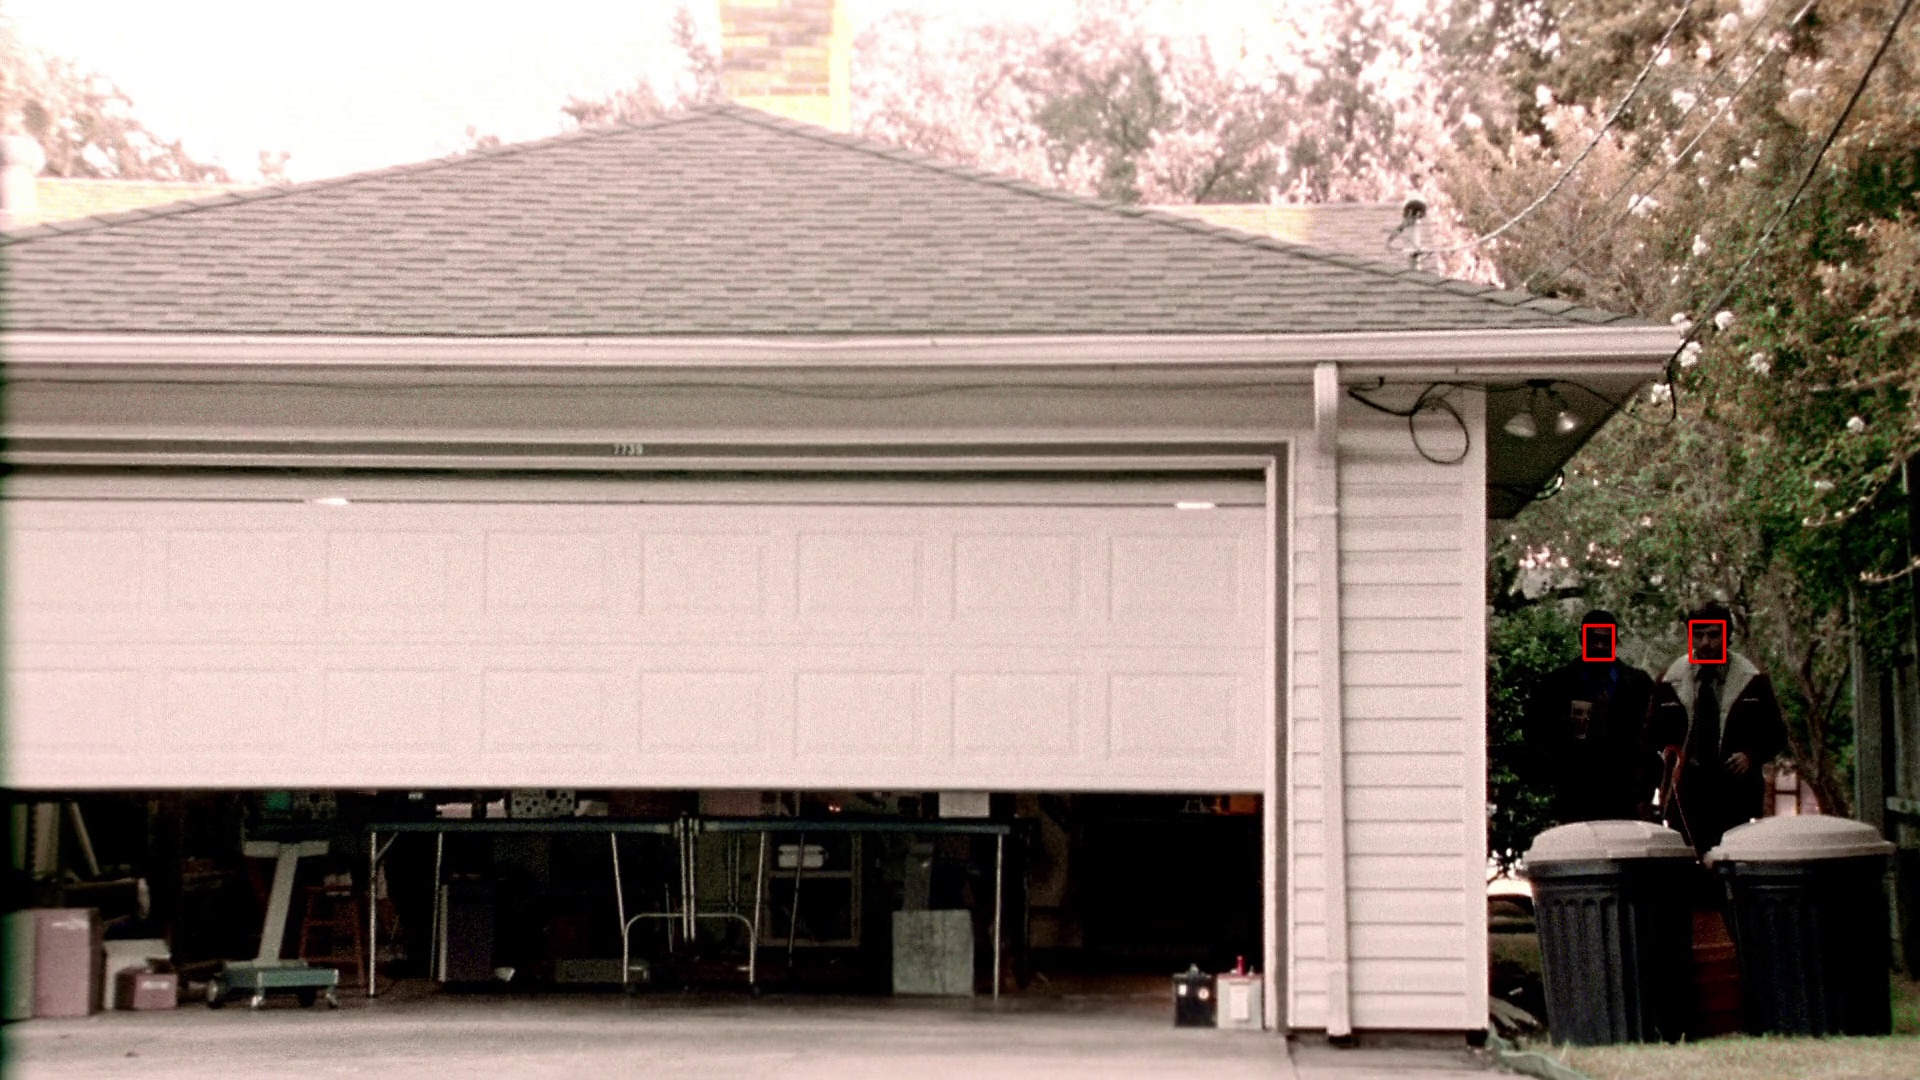

24


In [40]:
cap.read()
cnt = 1
framecount = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
pb = tqdm(total=framecount)
while True:
    if cnt % 24 == 0:
        ret, frame = cap.read()
        if not ret or frame is None:
            break 
        faces = RetinaFace.detect_faces(frame)
        if not faces:
            pb.update(1)
            cnt += 1
            continue
        draw_faces(frame, faces)
        show_image(frame)
        break
    cnt += 1
    pb.update(1)
print(cnt)
        